# Build FInal Single Factor Model 
## Setup Jupyter Notebook
### Import packages

In [75]:
# Import external packages
import pandas as pd
import os
import numpy as np
import random 
import pyarrow.parquet as pq
import sys
import shutil
import pickle
import warnings
from itertools import chain

from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_percentage_error

from pygam import GAM, s, te, f, l

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import LogLocator

import optuna
from optuna.visualization import matplotlib as optunampl

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 260)
warnings.filterwarnings("ignore")

In [3]:
# Import the internal package
package_loc = r"../"

# Add the package location to system paths
sys.path.append(package_loc)

from src import utils
from src.gam import training, explain

### Define Paths

In [49]:
###########################################################################
###########################################################################

data_version = "v2"
model_version = "v3"

###########################################################################
###########################################################################

# Define the directories for input and output
dir_input = f"input"
dir_data = f"export"
dir_output = f"output"

model_data_file = f"{dir_data}/gam_modelling_data_{data_version}.parquet"
modelling_log_03 = f"{dir_output}/03_model_note_{model_version}.xlsx"
modelling_log = f"output/04_model_note_{model_version}.xlsx"
model_filename = f"{dir_output}/gam_sf_{model_version}.pkl"

# Define the name of the rating tables that defines the GAM model 
final_sf_rating_table_output = f"{dir_output}/final_single_factor_rating_tables_{model_version}.pkl"


print(os.listdir(dir_input))
print(os.listdir(dir_data))
print(os.listdir(dir_output))

['.gitkeep', 'CMI TA DB 2016 Datasheet v02 2024-06-17.xlsb', 'CMI TA DB 2017 Datasheet v02 2024-06-17.xlsb', 'CMI TA DB 2018 Datasheet v01 2022-05-20.xlsb', 'CMI TA DB 2019 Datasheet v01 2022-05-20.xlsb', 'CMI TA DB 2020 Datasheet v01 2022-05-20.xlsb']
['CMI Categorical Bands (with CalendarYear).xlsx', 'gam_modelling_data_v2.parquet']
['02_model_note_v3.xlsx', '03_model_note_v3.xlsx', 'gam_initial_v3.pkl', 'single_factor_rating_tables_v3.pkl', 'training_data_folds_v3.pkl']


### Set Variables

In [8]:
title_fontsize = 25
label_fontsize = 20
ticker_fontsize = 15

## Create Modelling Data
### Inspect the pruning progress

In [6]:
###########################################################################
###########################################################################

factors_tab = "Factors_Used"
pruning_tab = "Prune_Progress"

###########################################################################
###########################################################################

# Import the factor tracking tab
factorstracking_df = pd.read_excel(f"{modelling_log_03}", factors_tab)
# Import the pruning progress tab
factor_prune_df = pd.read_excel(f"{modelling_log_03}", pruning_tab)

Text(0, 0.5, '')

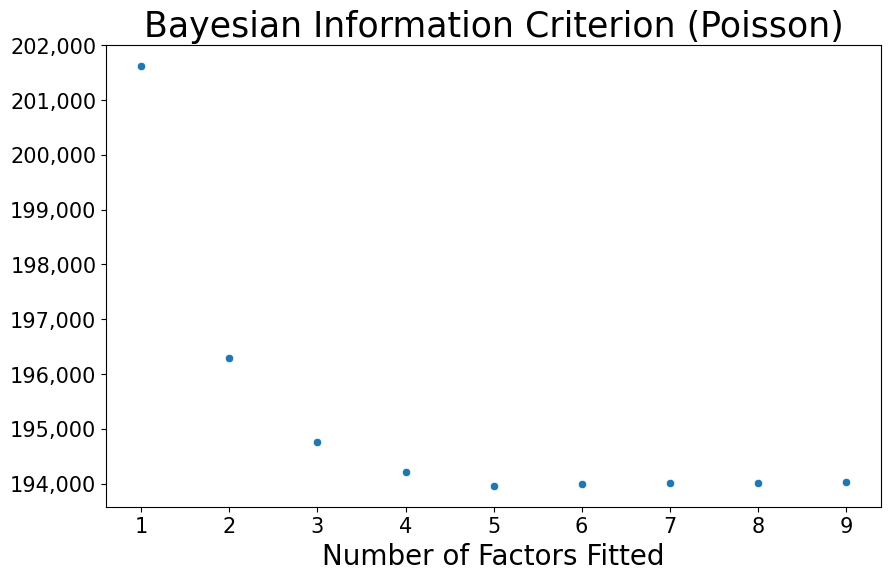

In [9]:
plt.rcParams["figure.figsize"] = [10, 6]
fig, ax = plt.subplots(1)
plt.rcParams["axes.edgecolor"] = "0.15"
plt.rcParams["axes.linewidth"] = 1.25

sns.scatterplot(
    data=factor_prune_df, x="num_factors", y="bic_poisson", ax=ax, color=["tab:blue"]
)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))
ax.tick_params(axis="both", which="major", labelsize=ticker_fontsize)
ax.grid(False)
ax.set_facecolor("white")

ax.set_title("Bayesian Information Criterion (Poisson)", fontsize=title_fontsize)
ax.set_xlabel("Number of Factors Fitted", fontsize=label_fontsize)
ax.set_ylabel("")

In [16]:
# Define the final set of features used in the model
iter_num = factor_prune_df.loc[
    (factor_prune_df["bic_poisson"] == factor_prune_df["bic_poisson"].min()), "iter"
].values[0]
final_feature = factorstracking_df.iloc[iter_num]
final_feature = final_feature.dropna().tolist()

# Include calandar year if not already in the final features - important for Covid
if "CalendarYear" not in final_feature:
    final_feature += ["CalendarYear"]
print(final_feature)

['Age', 'SmokerStatus', 'Duration', 'Gender', 'SumAssuredBand', 'CalendarYear']


### Import modelling data

In [ ]:
model_data = pd.read_parquet(f"{model_data_file}")
model_data

In [31]:
###########################################################################
###########################################################################

claim_count = "IncurredClaims"
claim_freq = "AnnualFreq"
weight = "LivesExposure"

# Define the list of numerical features
num_feat = [
    "SumAssuredBand",
    "Age",
    "Duration",
]

# Define the list of categorical features
cat_feat = [
    "ProductCategory_cat_level",
    "Gender_cat_level",
    "SmokerStatus_cat_level",
    "DistributionChannel_cat_level",
    "JointLifeStatus_cat_level",
    "CalendarYear_cat_level",
]

###########################################################################
###########################################################################

# Define the target for GAM
model_data[claim_freq] = model_data[claim_count] / model_data[weight]

num_feat_final = [x for x in num_feat if x in final_feature]
cat_feat_final = [
    x for x in cat_feat if x.replace("_cat_level", "") in final_feature
]

# Define the full feature list
all_feat_final = num_feat_final + cat_feat_final
print(all_feat_final)

['SumAssuredBand', 'Age', 'Duration', 'Gender_cat_level', 'SmokerStatus_cat_level', 'CalendarYear_cat_level']


In [32]:
# Check the number of rows with null target
print(model_data[model_data[claim_freq].isnull()].shape[0])

1192


In [ ]:
# Null values in the target are caused by zero exposure in the data
model_data[model_data[claim_freq].isnull()].head()

In [ ]:
# Need to remove rows with 0 exposures
model_data = model_data[
    ~((model_data[claim_freq].isnull()) | (model_data[claim_freq] == np.inf))
]
model_data

In [35]:
# Count null values for all columns
model_data.isnull().sum()

ProductCategory                  0
Gender                           0
SmokerStatus                     0
DistributionChannel              0
CommencementYear                 0
JointLifeStatus                  0
SumAssuredBand                   0
Age                              0
Duration                         0
LivesExposure                    0
AmountsExposure                  0
IncurredClaims                   0
AmountIncurred                   0
ExpectedClaims                   0
ExpectedAmountClaims             0
ComparatorTable                  0
CalendarYear                     0
holdout                          0
random_fold                      0
ProductCategory_cat_level        0
Gender_cat_level                 0
SmokerStatus_cat_level           0
DistributionChannel_cat_level    0
JointLifeStatus_cat_level        0
CalendarYear_cat_level           0
AnnualFreq                       0
dtype: int64

### Define required dataframes

In [38]:
###########################################################################
###########################################################################

training_folds_files = f"{dir_output}/training_data_folds_{model_version}.pkl"

###########################################################################
###########################################################################

with open(f"{dir_output}/training_data_folds_{model_version}.pkl", "rb") as file:
    X_train_rs, y_train_rs, w_train_rs, folds, base_adj = pickle.load(file)

X_train_rs = X_train_rs[all_feat_final]

print(f"Base Adjustment: {base_adj:.4f}")

Base Adjustment: 0.7744


In [82]:
###########################################################################
###########################################################################

holdout = "holdout"
random_fold = "random_fold"
num_fold = 5  # Number of folds in the training data

###########################################################################
###########################################################################

X_train = model_data.loc[model_data[holdout] == 0, all_feat_final]
y_train = model_data.loc[model_data[holdout] == 0, claim_freq]
w_train = model_data.loc[model_data[holdout] == 0, weight]

X_test = model_data.loc[model_data[holdout] == 1, all_feat_final]
y_test = model_data.loc[model_data[holdout] == 1, claim_freq]
w_test = model_data.loc[model_data[holdout] == 1, weight]

In [40]:
# Create a term string for GAM training
term_string, num_feat_map, cat_feat_map, _ = training.create_term_structure(
    num_feat_final,
    cat_feat_final,
    X_train_rs,
)
print(term_string)

s(0, lam=lam_num, n_splines=n_splines)+ s(1, lam=lam_num, n_splines=n_splines)+ s(2, lam=lam_num, n_splines=n_splines) + f(3, lam=lam_cat) + f(4, lam=lam_cat) + f(5, lam=lam_cat)


In [ ]:
# In any unseen data, any categorical level not in the training set will be mapped to the mode of the training set
for v in cat_feat_final:
    unique_level = X_train_rs[v].unique()
    condition = X_test[v].isin(unique_level)
    X_test[v] = np.where(condition, X_test[v], X_train_rs[v].mode().iloc[0])
X_test

In [43]:
# Create training and validation sets for each permutation of the random folds
X_train_cv = {}
X_valid_cv = {}
w_train_cv = {}
w_valid_cv = {}
y_train_cv = {}
y_valid_cv = {}

for i, (train_index, valid_index) in enumerate(folds):
    X_train_cv[i] = X_train_rs.iloc[train_index]
    X_valid_cv[i] = X_train_rs.iloc[valid_index]

    # Any unseen level in the validation fold needs to be replaced by the mode in the training folds
    for v in cat_feat_map.values():
        unique_level = X_train_cv[i][v].unique()
        condition = X_valid_cv[i][v].isin(unique_level)
        X_valid_cv[i][v] = np.where(
            condition, X_valid_cv[i][v], X_train_cv[i][v].mode().iloc[0]
        )

    w_train_cv[i] = w_train_rs.iloc[train_index]
    w_valid_cv[i] = w_train_rs.iloc[valid_index]
    y_train_cv[i] = y_train_rs.iloc[train_index]
    y_valid_cv[i] = y_train_rs.iloc[valid_index]

## Hyperparameter Tuning

In [44]:
# create study
study = optuna.create_study(direction="minimize")

# define objective
objective = training.OptunaGamObjectiveCV(
    term_string,
    5,
    (6, 10),  # Need to experiment with the range
    (1, 1e3, True),
    (1, 1e3, True),
    X_train_cv,
    X_valid_cv,
    y_train_cv,
    y_valid_cv,
    w_train_cv,
    w_valid_cv,
)

[I 2026-04-12 18:02:46,394] A new study created in memory with name: no-name-18a2b0e4-0c17-418d-9004-dbe20ccde7e5


In [45]:
###########################################################################
###########################################################################

n_trials = 30

###########################################################################
###########################################################################

# do study
study.optimize(objective, n_trials=n_trials)

[I 2026-04-12 18:07:39,600] Trial 0 finished with value: 193709.4116474449 and parameters: {'n_splines': 9, 'lam_num': 72.02850897878696, 'lam_cat': 7.676945504166664, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 0 with value: 193709.4116474449.
[I 2026-04-12 18:12:32,894] Trial 1 finished with value: 193740.0017747228 and parameters: {'n_splines': 9, 'lam_num': 372.9465349953275, 'lam_cat': 2.9833464867976702, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 0 with value: 193709.4116474449.
[I 2026-04-12 18:16:19,588] Trial 2 finished with value: 193759.2716734463 and parameters: {'n_splines': 7, 'lam_num': 173.67138615287422, 'lam_cat': 8.467551070025156, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 0 with value: 193709.4116474449.
[I 2026-04-12 18:20:28,256] Trial 3 finished with value: 193703.06831453537 and parameters: {'n_splines': 7, 'lam_num': 8.064946993899152, 'lam_cat': 69

In [46]:
# Print best trial
best_trial_number = study.best_trial.number
best_trial_value = study.best_trial.value
print(f"Best trial: {best_trial_number} with value {best_trial_value}\n{'*'*80}")

# Print out the best parameters
best_hyperparams = study.best_params
print(best_hyperparams)

Best trial: 13 with value 193690.74058762705
********************************************************************************
{'n_splines': 9, 'lam_num': 1.2358140438095957, 'lam_cat': 45.47437702430798, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}


In [ ]:
with pd.ExcelWriter(f"{modelling_log}", engine="openpyxl", mode="w") as writer:
    study.trials_dataframe().sort_values("value").to_excel(
        writer, sheet_name="Final_Tune", index=False
    )

<Axes: title={'center': 'Empirical Distribution Function Plot'}, xlabel='Objective Value', ylabel='Cumulative Probability'>

<Figure size 1000x600 with 0 Axes>

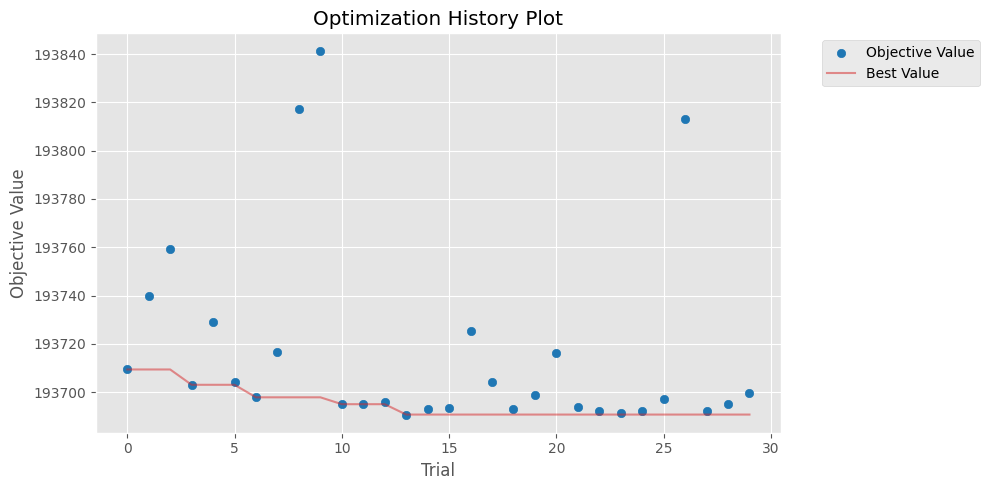

<Figure size 1000x500 with 0 Axes>

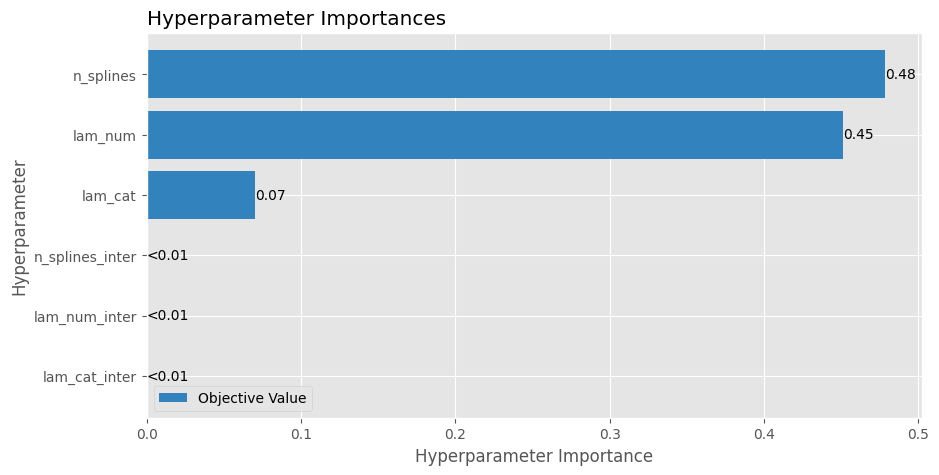

<Figure size 1000x500 with 0 Axes>

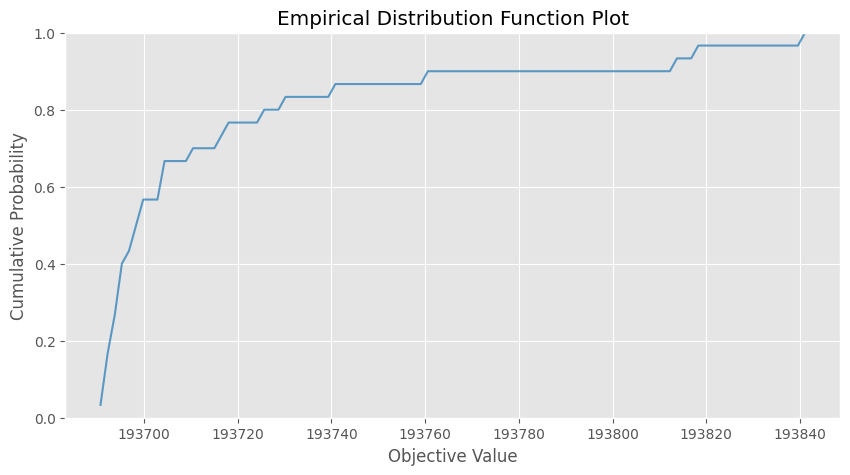

In [51]:
plt.figure()
plt.rcParams["figure.figsize"] = [10, 5]
optunampl.plot_optimization_history(study)

plt.figure()
plt.rcParams["figure.figsize"] = [10, 5]
optunampl.plot_param_importances(study) # Plot parameter importance

plt.figure()
plt.rcParams["figure.figsize"] = [10, 5]
optunampl.plot_edf(study) # Plot the empirical cumulative distribution plot

array([<Axes: xlabel='lam_cat', ylabel='Objective Value'>,
       <Axes: xlabel='lam_num'>, <Axes: xlabel='n_splines'>], dtype=object)

<Figure size 1000x500 with 0 Axes>

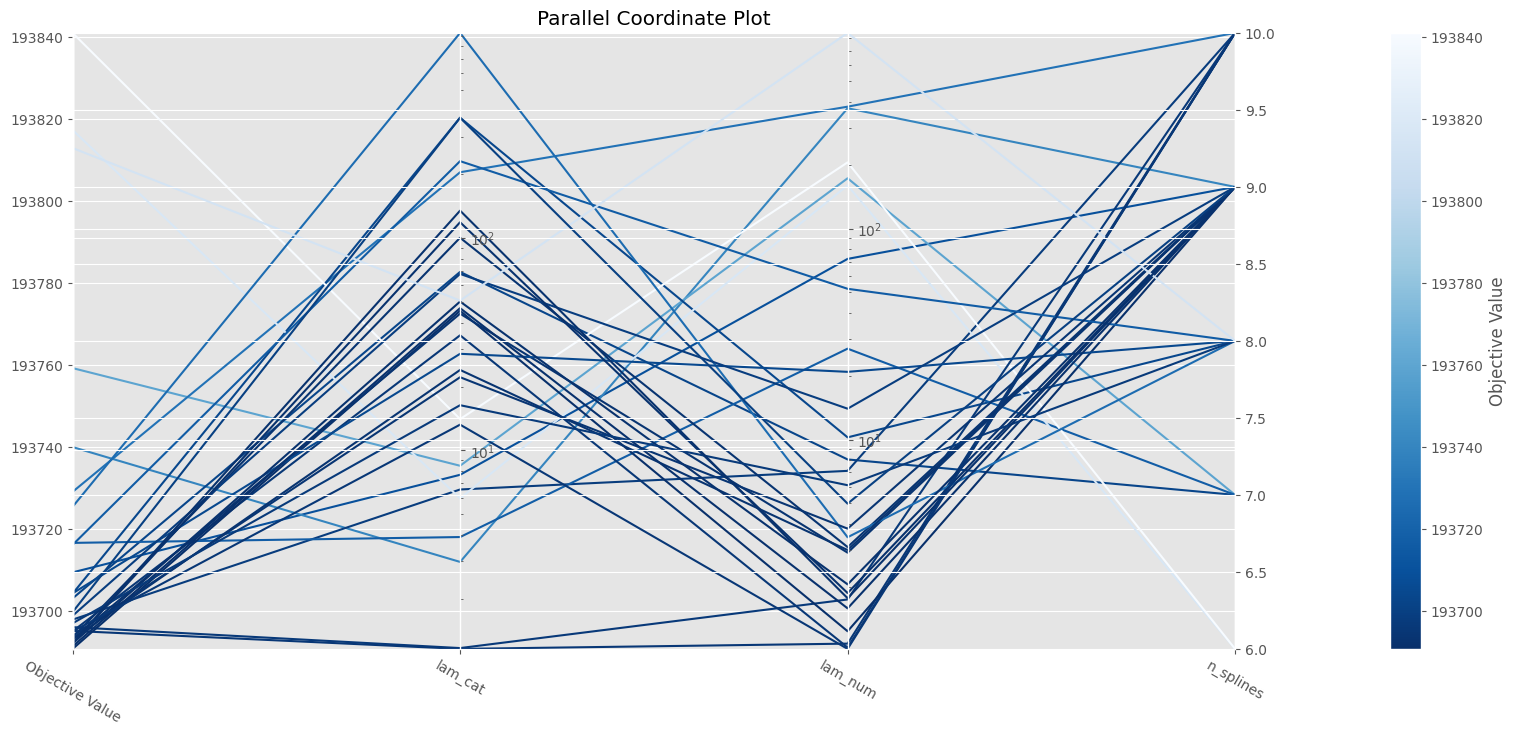

<Figure size 2000x800 with 0 Axes>

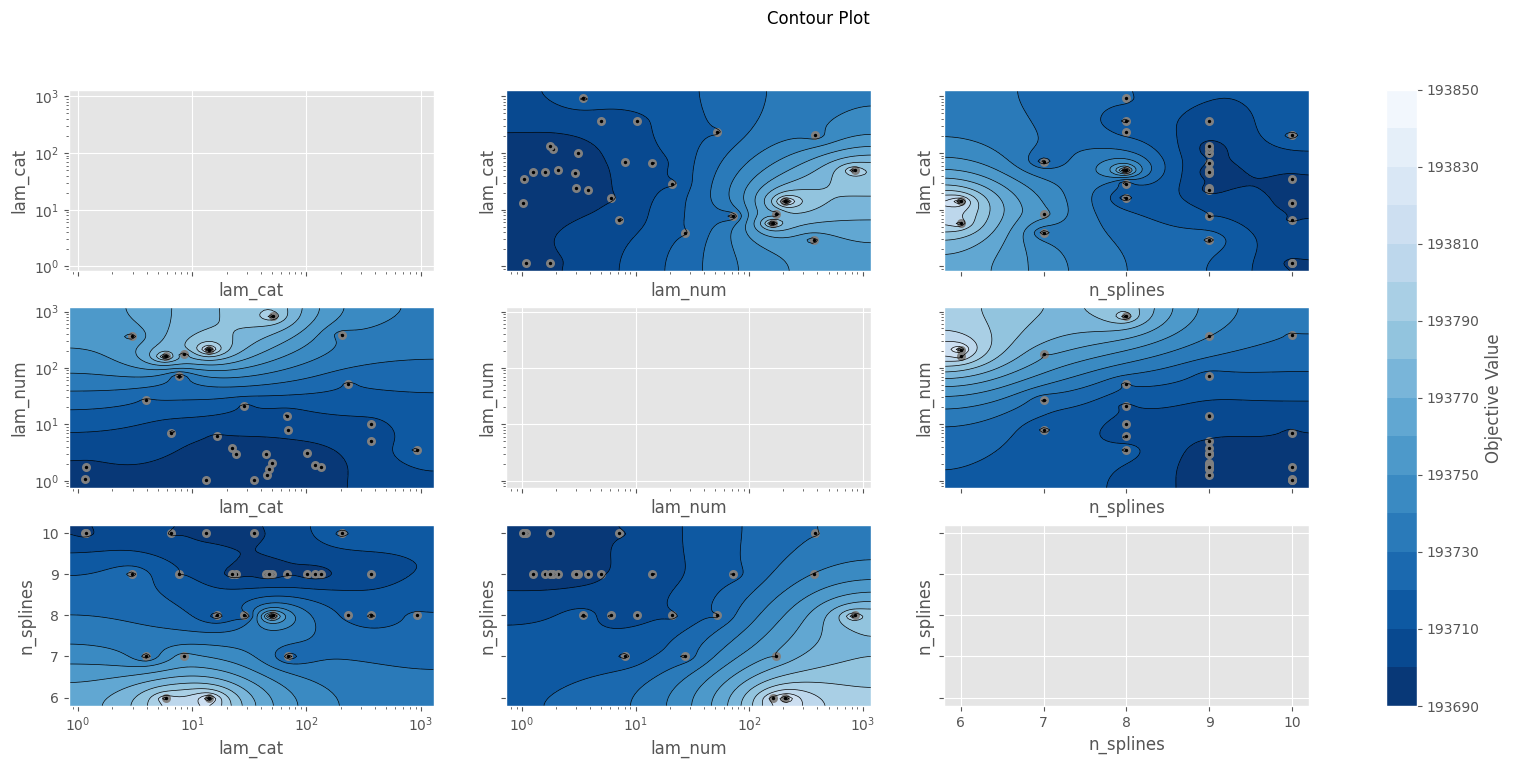

<Figure size 2000x800 with 0 Axes>

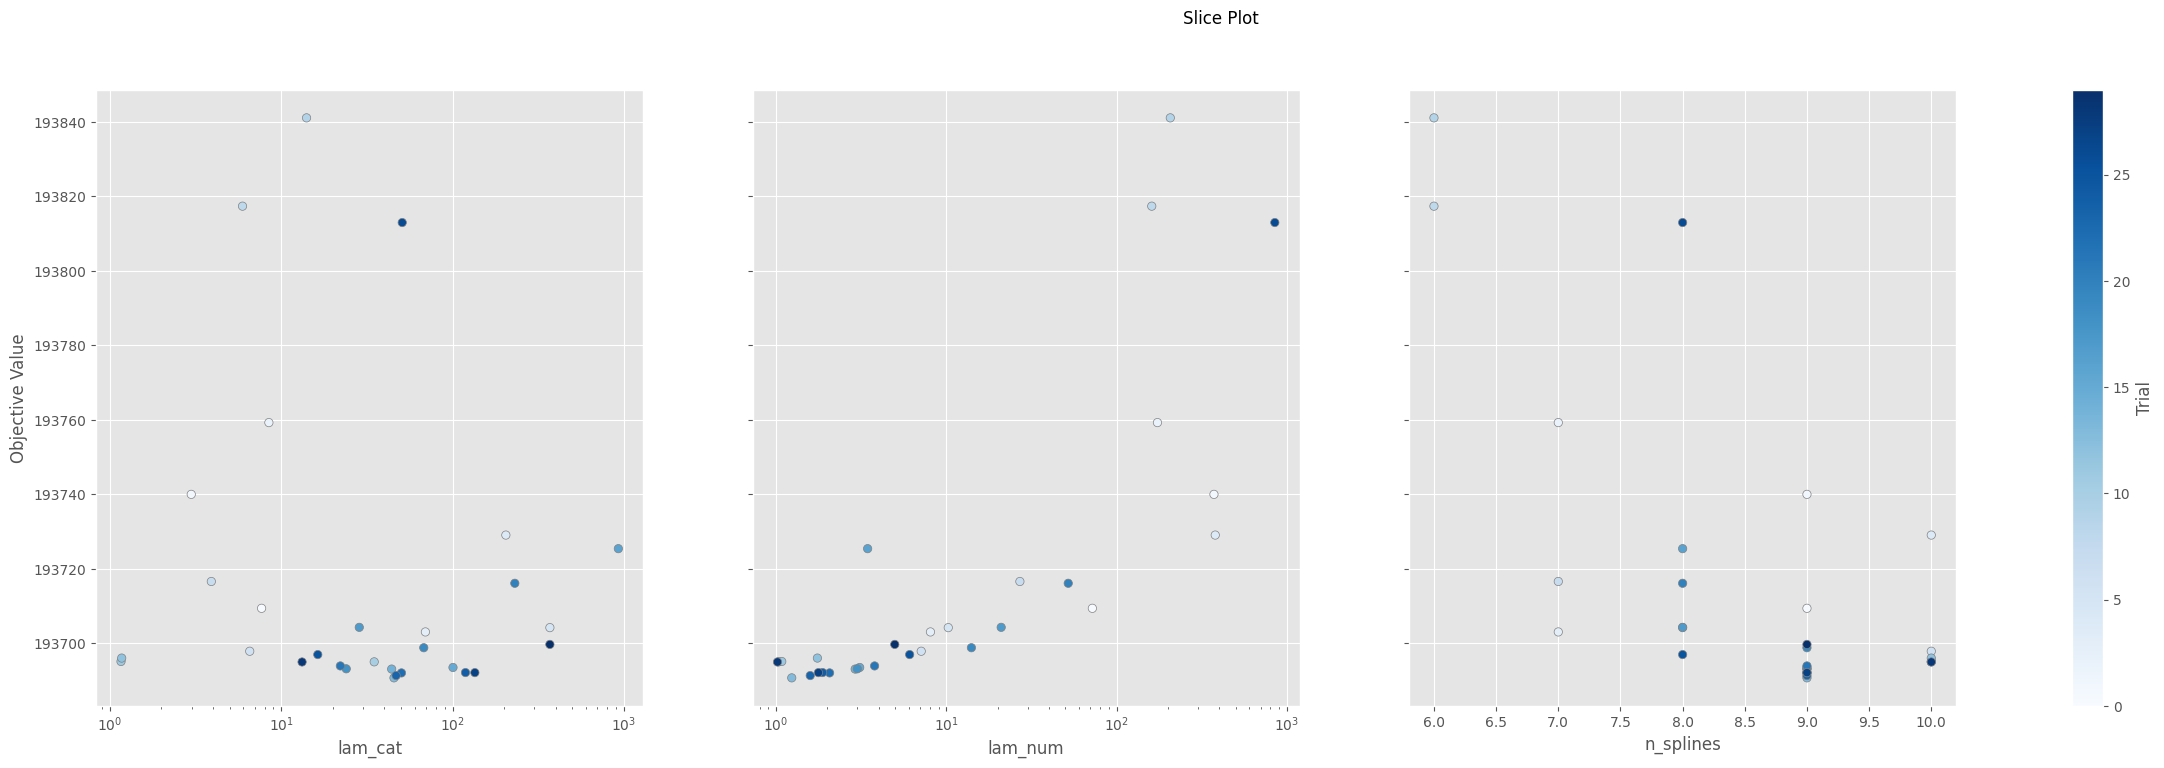

In [52]:
param_importance = optuna.importance.get_param_importances(study)

plt.figure()
plt.rcParams["figure.figsize"] = [20, 8]
optunampl.plot_parallel_coordinate(study, params=list(param_importance)[:3])

plt.figure()
plt.rcParams["figure.figsize"] = [20, 8]
optunampl.plot_contour(study, params=list(param_importance)[:3])

plt.figure()
plt.rcParams["figure.figsize"] = [20, 8]
optunampl.plot_slice(study, params=list(param_importance)[:3])

## Train Single Factor GAM Model

In [53]:

study_df = pd.read_excel(f"{modelling_log}", "Final_Tune")
best_params = study_df.sort_values("value").filter(regex="params_").iloc[0].to_dict()
best_params = {k.replace("params_", ""): v for k, v in best_params.items()}

n_splines = int(best_params["n_splines"])
lam_num = best_params["lam_num"]
lam_cat = best_params["lam_cat"]

print(f"n_splines: {n_splines}")
print(f"lam_num: {lam_num}")
print(f"lam_cat: {lam_cat}")

n_splines: 9
lam_num: 1.235814043809596
lam_cat: 45.47437702430798


In [54]:
# Fit the GAM model
gam_single = GAM(
    eval(term_string),
    distribution="poisson",
    link="log",
).fit(X_train_rs, y_train_rs, weights=w_train_rs)

gam_single.summary()

GAM                                                                                                       
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                     24.2177
Link Function:                          LogLink Log Likelihood:                                       -inf
Number of Samples:                      1535099 AIC:                                                   inf
                                                AICc:                                                  inf
                                                UBRE:                                               2.1262
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.6414
Feature Function                  Lam

In [55]:
# Save the GAM model as a pickle file 
with open(model_filename, 'wb') as file:
    pickle.dump(gam_single, file)

### Derive associated relativities

In [56]:
# Re-load the GAM model
with open(model_filename, "rb") as file:
    gam_single = pickle.load(file)

gam_single.summary()

GAM                                                                                                       
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                     24.2177
Link Function:                          LogLink Log Likelihood:                                       -inf
Number of Samples:                      1535099 AIC:                                                   inf
                                                AICc:                                                  inf
                                                UBRE:                                               2.1262
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.6414
Feature Function                  Lam

In [57]:
# Get the intercept of GAM
intercept = np.exp(gam_single.coef_[-1])
print(f"GAM Intercept: {intercept:.2%}")

# Define a list of all variables used in the model
all_feat = list(num_feat_map.values()) + list(cat_feat_map.values())
number_factors = len(all_feat_final)

GAM Intercept: 1.64%


#### Numerical Variables

In [58]:
# Initilise an empty dictionary for numerical variables
num_rel_dict, intercept_adj_list0 = training.extract_gam_relativity_num(
    gam_single,
    X_train_rs,
    w_train_rs,
    num_feat_map,
    weight,
    intercept_adj_list=[],
)
# Check one set of relativities for a rating factor
num_rel_dict["Duration"]

,Duration,relativity,LivesExposure
0,0,0.489673,2.504579e+06
1,1,0.710418,2.274345e+06
2,2,0.876856,1.956081e+06
3,3,0.976021,1.771911e+06
4,4,1.023088,1.626020e+06
5,5,1.055329,1.447740e+06
6,6,1.106451,1.332483e+06
7,7,1.156688,1.218101e+06
8,8,1.172060,1.111779e+06
9,9,1.140533,1.011155e+06


#### Categorical Variables

In [59]:
###########################################################################
###########################################################################

# Define the directory for the categorical mapping spreadsheet
cat_map_table = f"{dir_data}/CMI Categorical Bands (with CalendarYear).xlsx"

###########################################################################
###########################################################################

cat_rel_dict, intercept_adj_list = training.extract_gam_relativity_cat(
    gam_single,
    X_train_rs,
    w_train_rs,
    cat_feat_map,
    weight,
    cat_map_table, 
    intercept_adj_list=intercept_adj_list0,
)
cat_rel_dict["Gender_cat_level"]

,Gender_cat_level,Gender,relativity,LivesExposure
0,0,F,0.862361,1.093854e+07
1,1,M,1.130672,1.152173e+07


#### Adjust Intercept Term

In [60]:
assert len(intercept_adj_list) == len(
    all_feat_final
), "# intercept multipliers is not equal to # terms in GAM. Please check!!"

# Perform the adjustment
intercept_final = intercept * np.prod(intercept_adj_list) * base_adj

utils.pretty_print("Intercept Values")
print(f"{'Original':<10}: {intercept:,.5%}")
print(f"{'Adjusted':<10}: {intercept_final:,.5%}")

----------------
Intercept Values
----------------
Original  : 1.63761%
Adjusted  : 0.12017%


#### Export Intercept and Relativities

In [61]:
# Define the output
rating_tables = (intercept_final, num_rel_dict, cat_rel_dict)
# Save
with open(final_sf_rating_table_output, "wb") as file: 
    pickle.dump(rating_tables, file) 

#### Control Testing

In [ ]:
###########################################################################
###########################################################################

new_model_freq = "gam_freq"
cmi_base = "ExpectedClaims"
cmi_freq = "cmi_freq"
new_model_count = "gam_claim_count"

###########################################################################
###########################################################################

# Re-load the rating table outputs
with open(final_sf_rating_table_output, "rb") as file:
    intercept_final, num_rel_dict, cat_rel_dict = pickle.load(file)

# Define a dataframe that contains predictions, target and weight
ypred_test = gam_single.predict(X_test) * base_adj

ypred_test_df = pd.DataFrame(ypred_test, columns=[new_model_freq], index=X_test.index)
ypred_test_df = (
    ypred_test_df.join(y_test)
    .join(w_test)
    .join(
        model_data[
            [
                claim_count,
                cmi_base,
            ]
        ]
    )
)
ypred_test_df[new_model_count] = ypred_test_df[new_model_freq] * ypred_test_df[weight]
ypred_test_df[cmi_freq] = ypred_test_df[cmi_base] / ypred_test_df[weight]
ypred_test_df

In [63]:
###############################################################
###############################################################

# Define the number of decimal places to round the predictions
rounding_num = 7

###############################################################
###############################################################

# Test on the training ata
ypred_train = gam_single.predict(X_train_rs) * base_adj

# Define a procedure to score a dataset using the relativities extracted
X_train_rel = X_train_rs.copy()
rel_list = []

for v, r in num_rel_dict.items():
    X_train_rel[v + "_rel"] = X_train_rel[v].map(r.set_index(v)["relativity"].to_dict())
    rel_list.append(v + "_rel")

for v, r in cat_rel_dict.items():
    X_train_rel[v.replace("_cat_level", "") + "_rel"] = X_train_rel[v].map(
        r.set_index(v)["relativity"].to_dict()
    )
    rel_list.append(v.replace("_cat_level", "") + "_rel")

# Check there are no null values
assert (
    X_train_rel.isnull().sum().sum() == 0
), "There are NA values in relativities calculated. Please check!!"


ypred_train_df = pd.DataFrame(
    ypred_train, columns=[new_model_freq], index=X_train_rs.index
)

ypred_train_df[f"{new_model_freq}_rel"] = (
    X_train_rel[rel_list].prod(axis=1) * intercept_final
)

check_df = ypred_train_df[
    ypred_train_df[new_model_freq].round(rounding_num)
    != ypred_train_df[f"{new_model_freq}_rel"].round(rounding_num)
]

# Check if there is any diff between the predictions from model and the predictions from rating tables
assert (
    len(check_df) == 0
), "There are differences detected between the model predictions and the predictions from rating tables. Please check!!"

### Holdout Assessment

In [64]:
# Poisson Deviance
gam_dev = utils.total_poisson_dev(
    y=ypred_test_df[claim_count],
    y_pred=ypred_test_df[new_model_count],
)
cmi_dev = utils.total_poisson_dev(
    y=ypred_test_df[claim_count],
    y_pred=ypred_test_df[cmi_base],
)

utils.pretty_print("Total Poisson Deviance")
print(f"{'GAM Model':<15}: {gam_dev:,.0f}")
print(f"{'CMI Base':<15}: {cmi_dev:,.0f}")

----------------------
Total Poisson Deviance
----------------------
GAM Model      : 52,929
CMI Base       : 52,946


In [65]:
corr, _ = pearsonr(
    ypred_test_df[cmi_freq], ypred_test_df[new_model_freq]
)
print(f"Correlation between GAM and CMI Base Rate: {corr:.2%}")

Correlation between GAM and CMI Base Rate: 98.45%


In [68]:
################################################################
################################################################

# Define the list of new to current model prediction column names
predict = [new_model_count, cmi_base]

################################################################
################################################################

d = utils.DoubleLift(
    ypred_test_df, predict, claim_count, weight, [0.00, 0.98], approx_num_band=20
)

mape_gam = mean_absolute_percentage_error(
    d.double_lift_table[claim_count],
    d.double_lift_table[predict[0]],
    sample_weight=d.double_lift_table[weight],
)
mape_expected = mean_absolute_percentage_error(
    d.double_lift_table[claim_count],
    d.double_lift_table[predict[1]],
    sample_weight=d.double_lift_table[weight],
)
print(f"{'MAPE - GAM':<30}: {mape_gam:.2%}")
print(f"{'MAPE - CMI Base':<30}: {mape_expected:.2%}")

d.double_lift_table

MAPE - GAM                    : 8.04%
MAPE - CMI Base               : 8.47%


,ratio_band,IncurredClaims,gam_claim_count,ExpectedClaims,LivesExposure
band,,,,,
1,"(0.473, 0.6]",0.000143,0.000173,0.000306,2.811480e+04
2,"(0.6, 0.7]",0.000407,0.000488,0.000729,1.125462e+05
3,"(0.7, 0.8]",0.001002,0.000909,0.001193,5.525859e+05
4,"(0.8, 0.9]",0.001132,0.001058,0.001236,1.415134e+06
5,"(0.9, 1.0]",0.001331,0.001280,0.001346,1.900574e+06
6,"(1.0, 1.1]",0.001607,0.001583,0.001512,1.457421e+06
7,"(1.1, 1.2]",0.001686,0.001793,0.001569,8.736225e+05
8,"(1.2, 1.3]",0.001529,0.001747,0.001408,4.083283e+05
9,"(1.3, 1.4]",0.000977,0.001178,0.000877,2.121467e+05


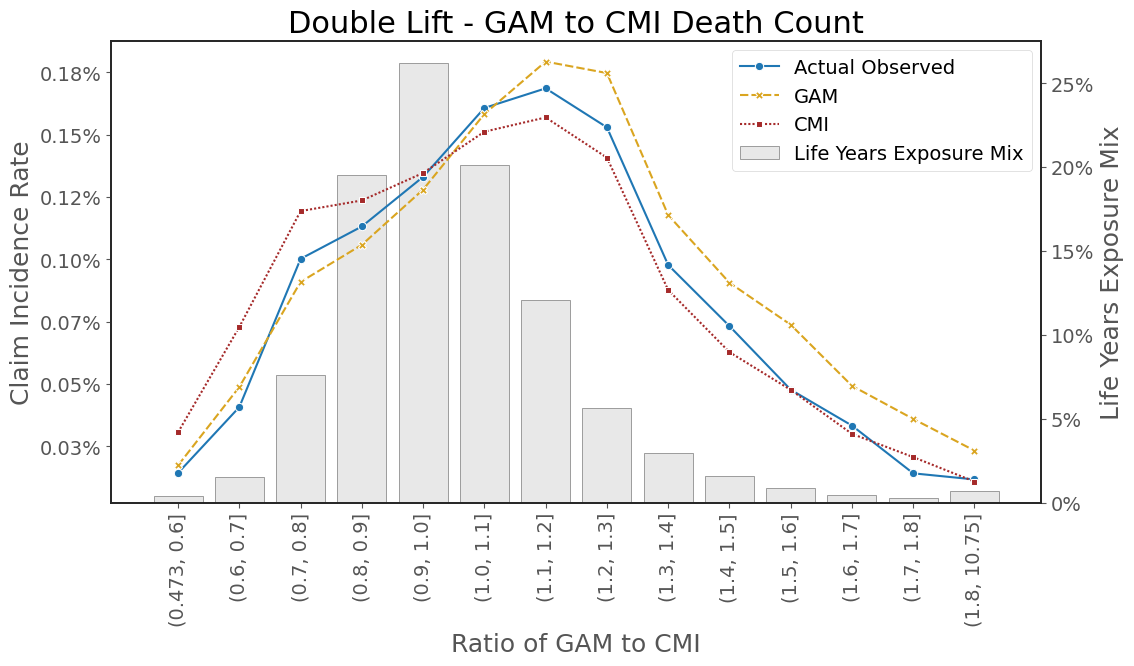

In [69]:
###########################################################################
###########################################################################

param_dict = {
    "title": "Double Lift - GAM to CMI Death Count", 
    "leftylabel": "Claim Incidence Rate", 
    "rightylabel": "Life Years Exposure Mix",
    "target_legend": "Actual Observed", 
    "new_model_legend": "GAM",
    "baseline_legend": "CMI",
    "palette": ["tab:blue", "#DAA520", "#A52A2A"]
}

###########################################################################
###########################################################################

plt.rcParams["axes.edgecolor"] = "0.15"
plt.rcParams["axes.linewidth"] = 1.25

fig, ax = plt.subplots(figsize=(12, 6))

d.plot_double_lift(ax=ax, **param_dict)

## Model Explanation 
### Factor Strength

In [71]:
single_fact_df, _ = explain.factor_strength(num_rel_dict, cat_rel_dict, weight="LivesExposure")
single_fact_df

,feature,feature_type,factor_strength
0,Age,numerical,1.410426
1,SmokerStatus,categorical,0.400108
2,Duration,numerical,0.241443
3,Gender,categorical,0.134110
4,SumAssuredBand,numerical,0.101941
5,CalendarYear,categorical,0.028588


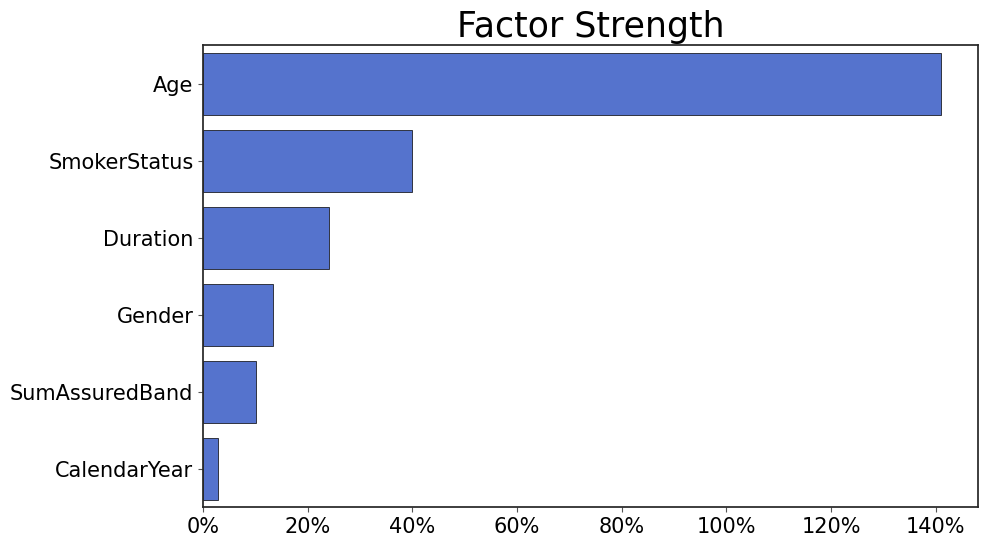

In [72]:
fig, ax = plt.subplots(1, figsize=(10, 6))
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.25

# Plot data
sns.barplot(
    x="factor_strength",
    y="feature",
    data=single_fact_df,
    ax=ax,
    color="royalblue",
    edgecolor="black",
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0%}"))
ax.tick_params(
    axis="both", which="major", labelsize=ticker_fontsize, labelcolor="black"
)
ax.set_title(f"Factor Strength", fontsize=title_fontsize)
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)
ax.set_facecolor("white")

In [73]:
# Append the factor strength table to the modelling log
with pd.ExcelWriter(
    f"{modelling_log}", engine="openpyxl", mode="a", if_sheet_exists="replace"
) as writer:
    single_fact_df.to_excel(writer, sheet_name="Final_Sing_Fac_Imp", index=False)

### Single Factor Trend Assessment

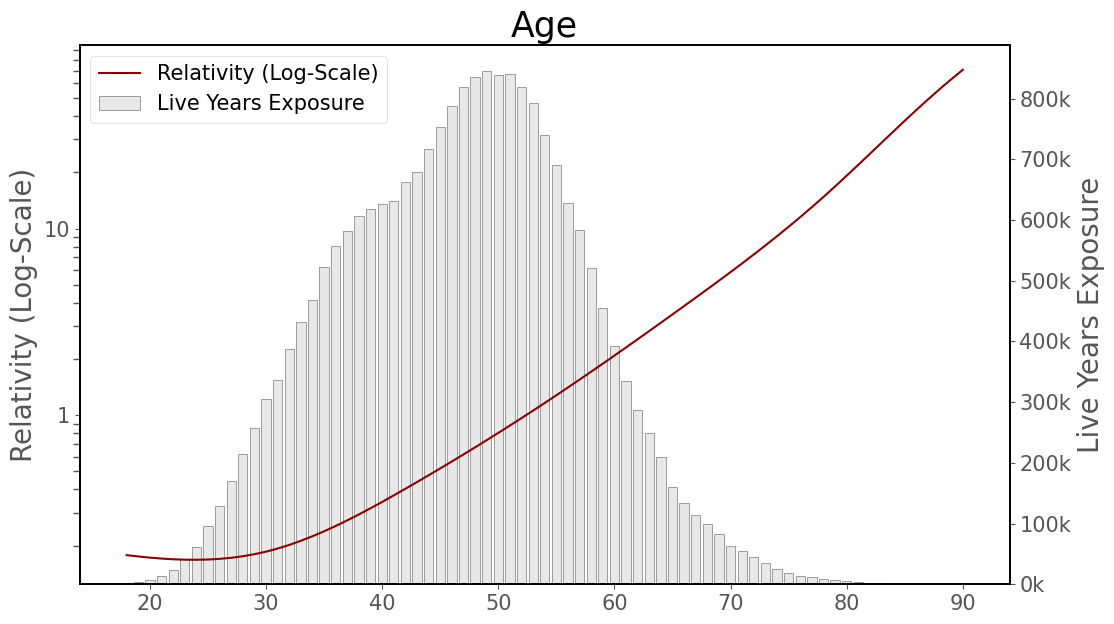

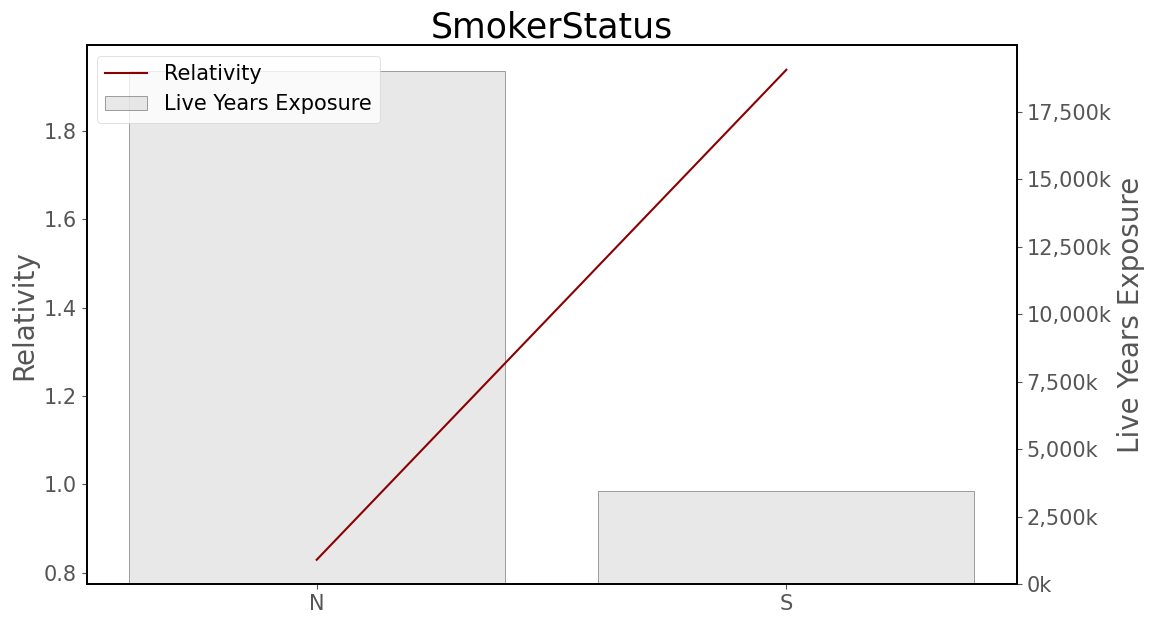

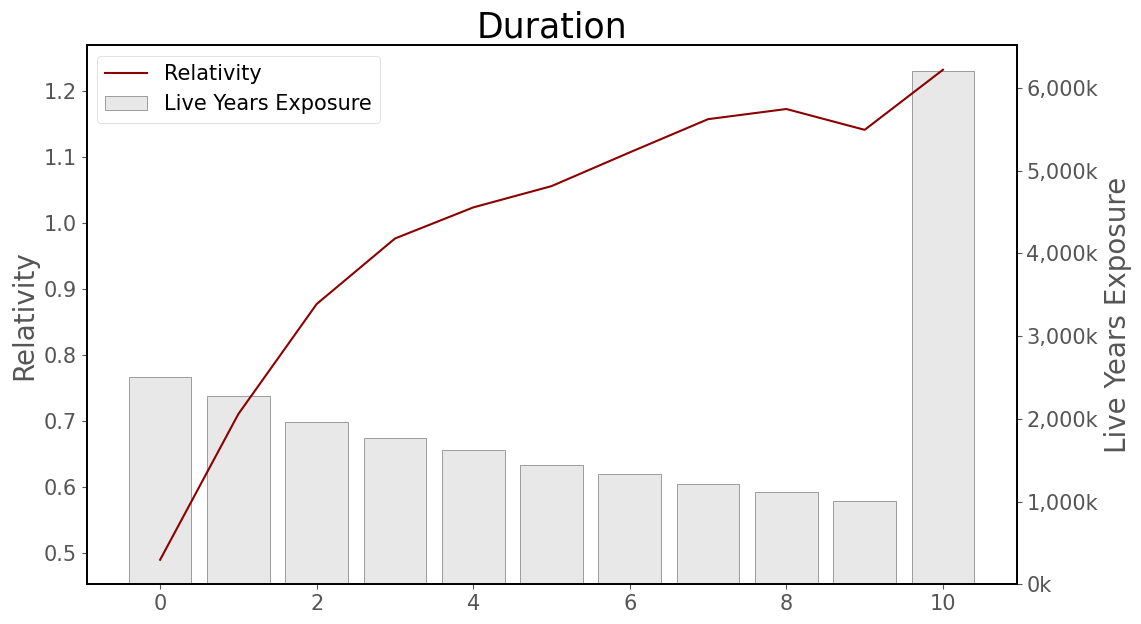

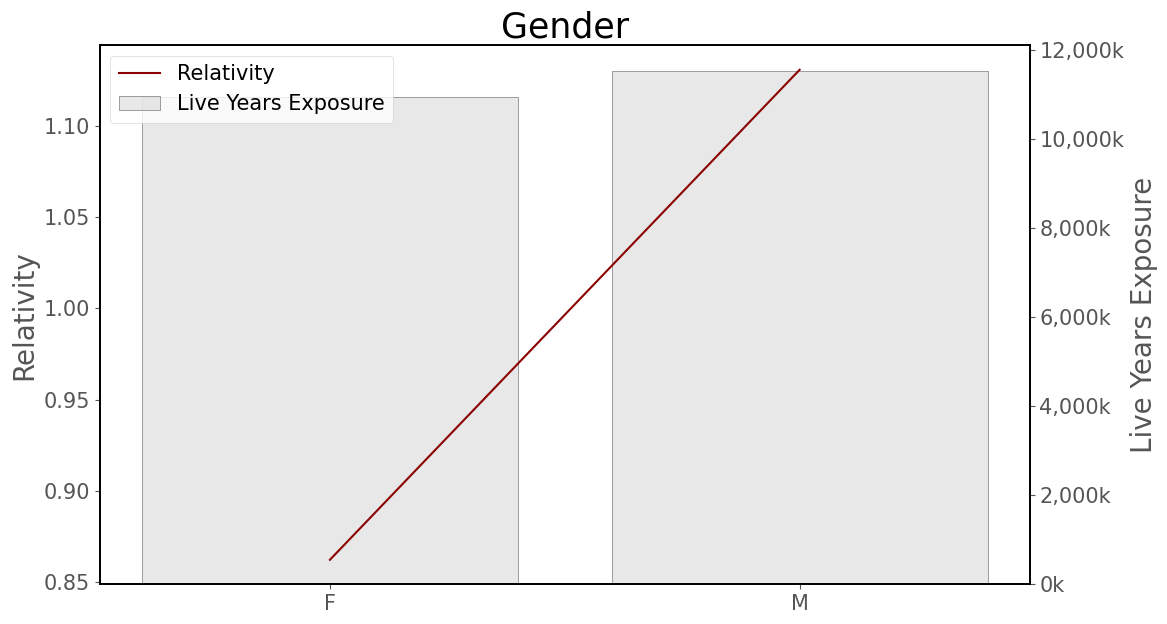

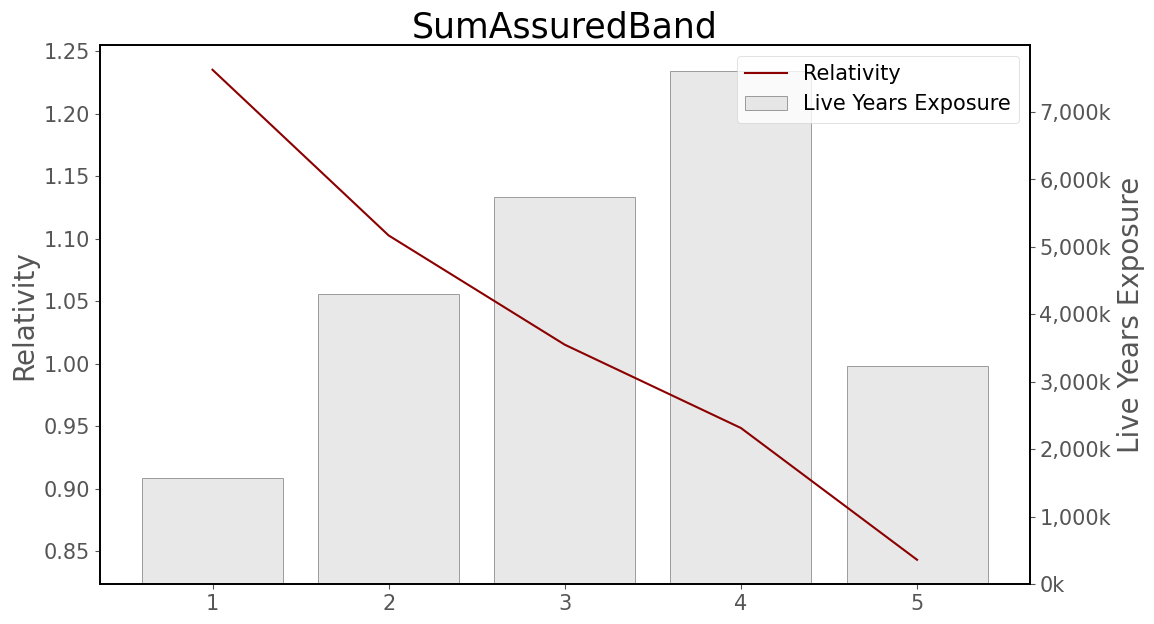

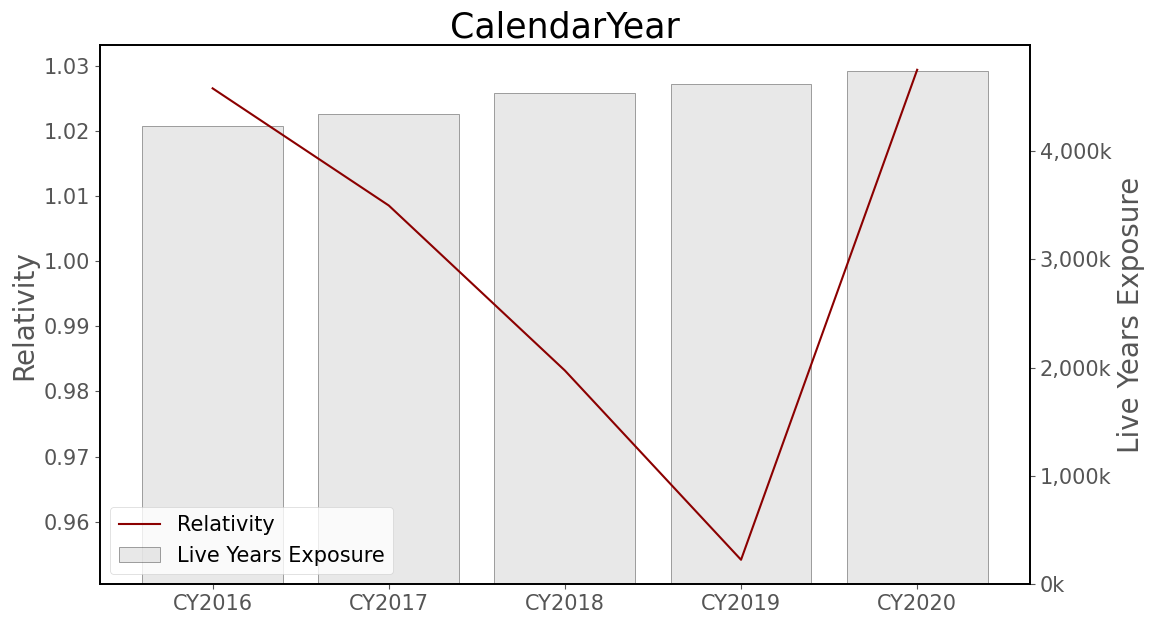

In [76]:
###################################################################
###################################################################

# Define the age variable
age_var = "Age"
rightylabel = "Live Years Exposure"
var_xtick_adj_list = []

###################################################################
###################################################################

for v in single_fact_df["feature"]:

    # Get the relativity table
    rel_table = (
        num_rel_dict[v] if v in num_rel_dict.keys() else cat_rel_dict[v + "_cat_level"]
    )
    rel_table = rel_table.set_index(v)
    # Start plotting
    fig, ax = plt.subplots(1, figsize=(12, 7))
    leftylabel = "Relativity (Log-Scale)" if v == age_var else "Relativity"

    sns.lineplot(data=rel_table["relativity"], ax=ax, color="darkred", label=leftylabel)

    ax.tick_params(axis="both", which="major", labelsize=ticker_fontsize)
    ax.set_xlabel("")
    ax.set_ylabel(leftylabel, fontsize=label_fontsize)
    ax.set_title(v.replace("_ordinal", ""), fontsize=title_fontsize)

    if v == age_var:
        ax.set_yscale("log")

        # Set specific tick locations
        ax.yaxis.set_major_locator(mtick.FixedLocator([1, 10]))

        # Format labels
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: "{:g}".format(y)))

        # Add minor ticks for gridlines
        ax.yaxis.set_minor_locator(
            LogLocator(base=10, subs=np.arange(2, 10), numticks=10)
        )
        ax.tick_params(axis="y", which="minor", length=5, width=1, direction="out")

    ax.grid(False)

    ax2 = ax.twinx()
    ax2.bar(
        rel_table.index,
        rel_table[weight],
        color="lightgray",
        alpha=0.5,
        ec="k",
        label=rightylabel,
    )
    # Format secondary y-axis ticker
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
    ax2.tick_params(axis="y", which="major", labelsize=ticker_fontsize)

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    bars, bar_labels = ax2.get_legend_handles_labels()
    ax.legend(
        lines + bars,
        labels + bar_labels,
        loc="best",
        fontsize=ticker_fontsize,
        facecolor="white",
    )
    # Set secondary y-axis label
    ax2.set_ylabel(rightylabel, fontsize=label_fontsize)

    if v in var_xtick_adj_list:
        xticks = rel_table.index.values
        if len(xticks) > 15:
            step = len(xticks) // 10
            xticks = xticks[::step]
        ax.set_xticks(xticks)

    # Define order of layering
    ax.set_zorder(2)
    ax.patch.set_alpha(0)
    ax2.set_zorder(1)

### Actual vs Expected Analysis on Holdout

In [77]:
##################################################################
##################################################################

key_features = [x.replace("_ordinal", "") for x in single_fact_df["feature"]]

##################################################################
##################################################################

# Initialise an empty dict for holding the grouped by dataframes
risk_agg_dict = {}


for v in key_features:
    # Perform risk aggregations by individual features
    df_gb = utils.risk_agg(
        ypred_test_df.join(model_data[key_features]),
        v,
        weight,
        claim_count,
        cmi_death_count=cmi_base,
        gam_death_count=new_model_count,
    )
    # We're doing Actual vs Expected analysis
    df_gb["cmi_death_rate"] = df_gb["actual_death_rate"] / df_gb["cmi_death_rate"]
    df_gb["gam_death_rate"] = df_gb["actual_death_rate"] / df_gb["gam_death_rate"]

    risk_agg_dict[v] = df_gb

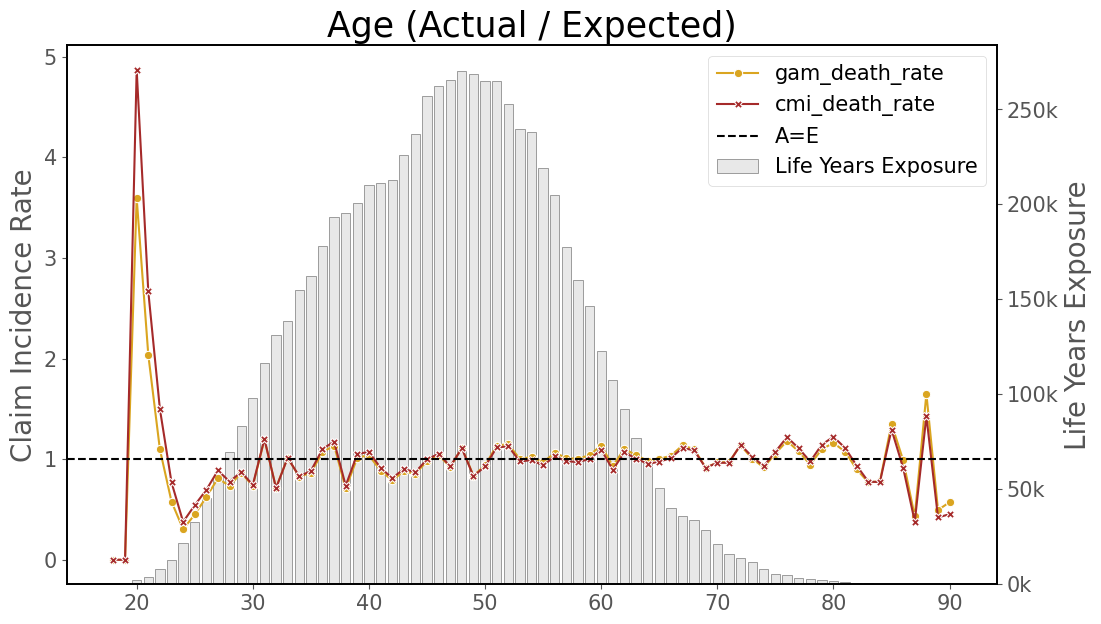

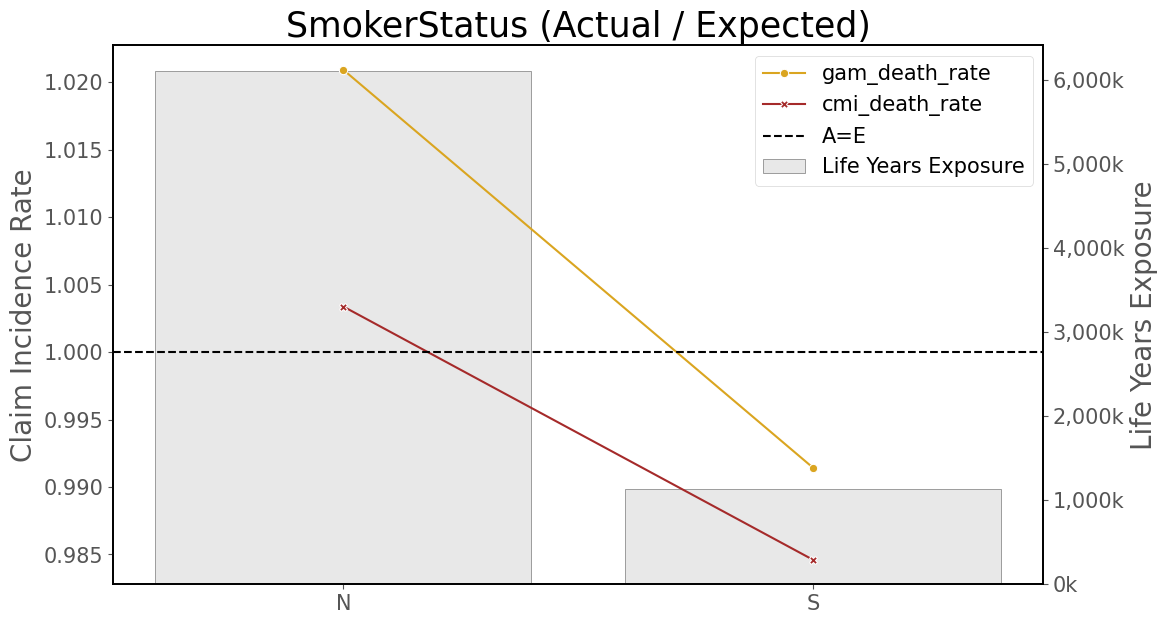

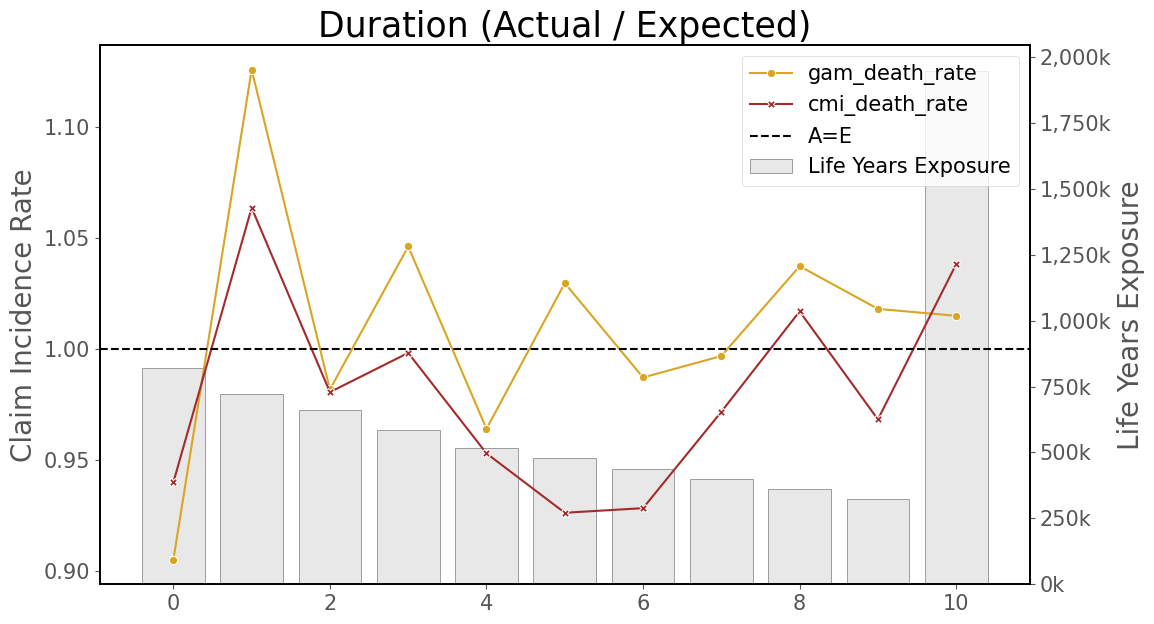

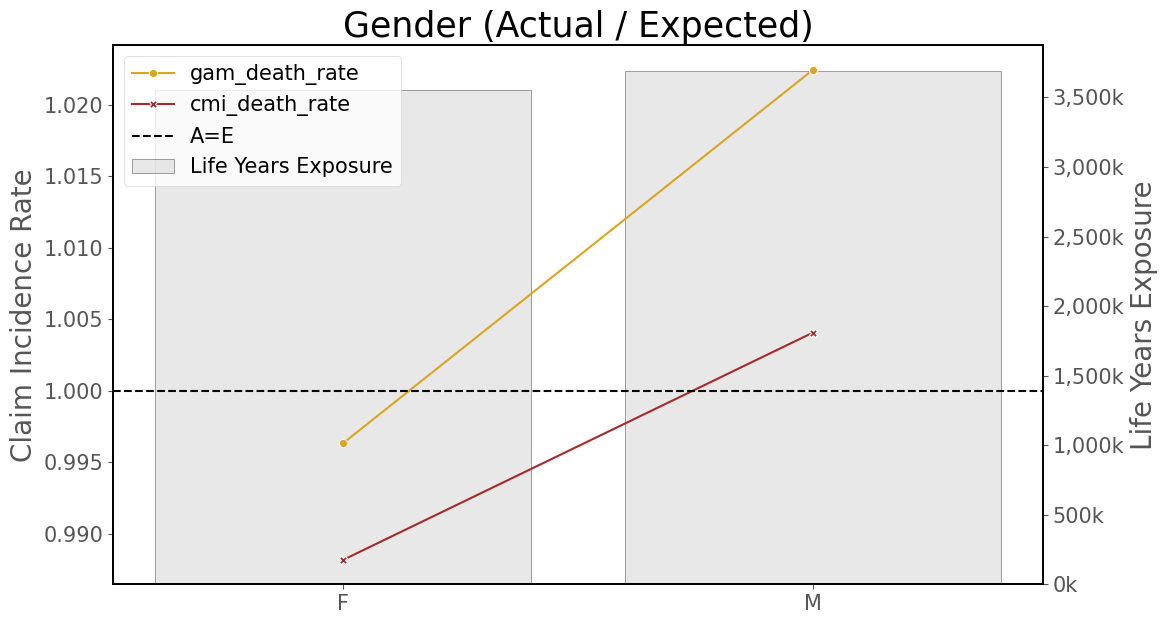

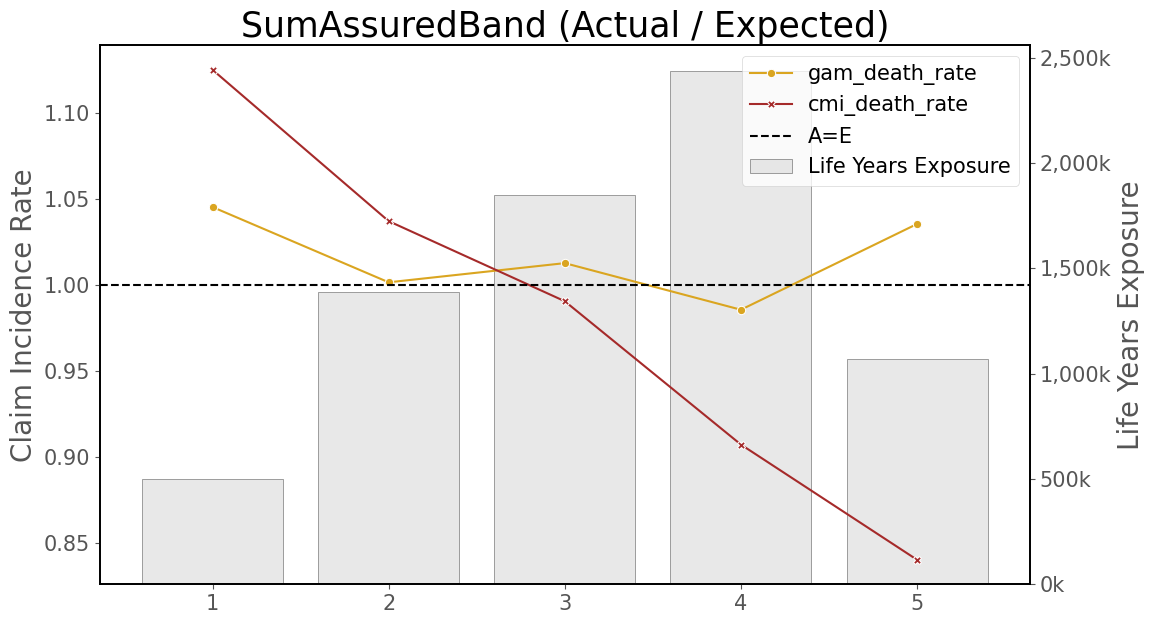

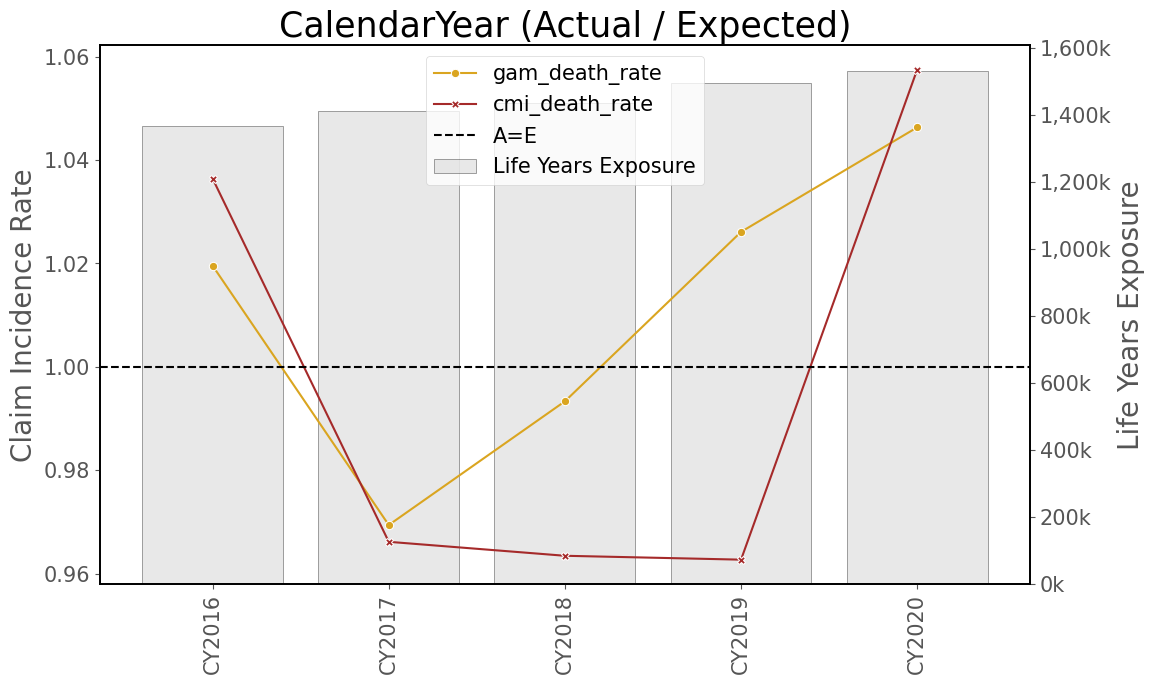

In [78]:
##############################################################################################
##############################################################################################

y1_label = "Claim Incidence Rate"
y2_label = "Life Years Exposure"

##############################################################################################
##############################################################################################

for var in key_features:

    fig, ax = plt.subplots(1, figsize=(12, 7))
    # Plot incidence rates
    sns.lineplot(
        data=risk_agg_dict[var].loc[
            :, ["gam_death_rate", "cmi_death_rate"]
        ],
        ax=ax,
        markers=True,
        dashes=False,
        palette=["#DAA520", "#A52A2A"],
    )
    ax.axhline(y=1, color="black", linestyle="--", label="A=E")

    # Set title and x and y axes labels and fontsize
    ax.set_ylabel(y1_label, fontsize=label_fontsize)
    ax.set_xlabel("")
    ax.set_title(var + " (Actual / Expected)", fontsize=title_fontsize)
    ax.tick_params(axis="both", which="major", labelsize=ticker_fontsize)

    # Fix the xticker labels if there are decimal places in xtickers when variable should be integers
    if not isinstance(risk_agg_dict[var].index[0], str):
        index_has_decimals = any(val % 1 != 0 for val in risk_agg_dict[var].index)
        ticks_have_decimals = any(tick % 1 != 0 for tick in ax.get_xticks())

        if not index_has_decimals and ticks_have_decimals:
            ax.set_xticks(risk_agg_dict[var].index)
            ax.set_xticklabels(risk_agg_dict[var].index)

    # Format x-axis tickers
    ax.tick_params(
        axis="x",
        rotation=(
            90
            if isinstance(risk_agg_dict[var].index[0], str)
            and len(risk_agg_dict[var].index[0]) > 4
            else 0
        ),
    )

    # Create secondary y-axis for exposures
    ax2 = ax.twinx()
    ax2.bar(
        risk_agg_dict[var].index,
        risk_agg_dict[var][weight],
        color="lightgray",
        alpha=0.5,
        ec="k",
        label=y2_label,
    )

    # Format secondary y-axis ticker
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
    ax2.tick_params(axis="y", which="major", labelsize=ticker_fontsize)

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    bars, bar_labels = ax2.get_legend_handles_labels()
    ax.legend(
        lines + bars,
        labels + bar_labels,
        loc="best",
        fontsize=ticker_fontsize,
        facecolor="white",
    )

    # Set secondary y-axis label
    ax2.set_ylabel(y2_label, fontsize=label_fontsize)

    # Define order of layering
    ax.set_zorder(2)
    ax.patch.set_alpha(0)
    ax2.set_zorder(1)
    ax.grid(False)

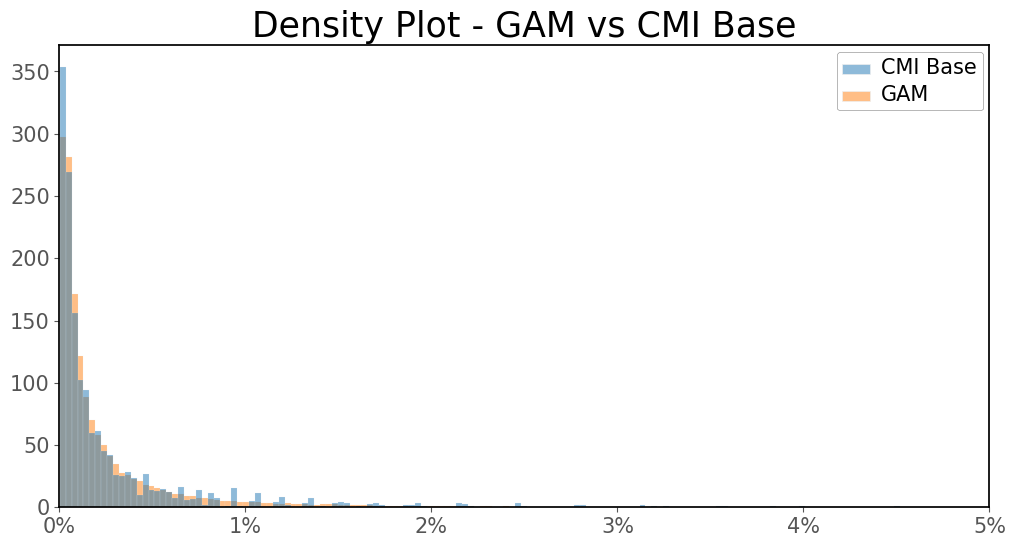

In [79]:
###########################################################################
###########################################################################

random_sample = 50000
random_seed = 999
color_list = ["tab:blue", "tab:orange"]
title = "Density Plot - GAM vs CMI Base"
x_axis_range = (0, 0.05)

###########################################################################
###########################################################################

dum = ypred_test_df[[cmi_freq, new_model_freq]].rename(
    columns={
        cmi_freq: "CMI Base",
        new_model_freq: "GAM",
    }
).sample(n=random_sample, random_state=random_seed)

plt.rcParams["figure.figsize"] = [12, 6]
fig, ax = plt.subplots(1)

sns.histplot(
    data=dum,
    kde=False,
    ax=ax,
    stat="density",
    palette=color_list,
    legend=True,
    alpha=0.5,
)

ax.set_xlim(x_axis_range[0], x_axis_range[1])
ax.set_title(title, fontsize=title_fontsize)
ax.tick_params(axis="both", which="major", labelsize=ticker_fontsize)
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0%}"))
ax.grid(False)
ax.set_facecolor("white")

legend = ax.get_legend()
legend.set_frame_on(True)  
legend.get_frame().set_facecolor('white') 
legend.get_frame().set_edgecolor('grey')  
for text in legend.get_texts():
    text.set_fontsize(ticker_fontsize)

## Save down single factor model predictions for interaction detections

In [ ]:
model_data_dum = model_data.copy()

for v in cat_feat_final:
    unique_level = X_train_rs[v].unique()
    condition = model_data_dum[v].isin(unique_level)
    model_data_dum[v] = np.where(
        condition, model_data_dum[v], X_train_rs[v].mode().iloc[0]
    )
model_data_dum

In [ ]:
ypred_df = pd.DataFrame(
    gam_single.predict(model_data_dum[X_train.columns]),
    index=model_data_dum.index,
    columns=[new_model_freq],
)
ypred_df[[weight, cmi_base, claim_count]] = model_data_dum[
    [weight, cmi_base, claim_count]
]
ypred_df[new_model_count] = ypred_df[new_model_freq] * ypred_df[weight]
ypred_df

In [85]:
#################################################################################
#################################################################################


ypred_sf_filename = f"export/gam_sf_pred_{model_version}.parquet"

#################################################################################
#################################################################################

ypred_df.to_parquet(ypred_sf_filename)